This is the document where one can actually train a classifier (the others scripts bring togethers objects, functions and tests that can be imported in this notebook).

In [ ]:
%load_ext line_profiler

## Imports

In [1]:
import src
from src.dataset_reader import download_dataset_from_internet, load_dataset

c:\Users\anato\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Download the dataset

In [ ]:
download_dataset_from_internet()

## Load the dataset into python objects

In [2]:
training_set, test_set = load_dataset(training_size=60000, old_format=True)

In [ ]:
print(training_set[0][0]) # Serait bien aussi de les visualiser. Je vais noter ça comme objectif.
print(training_set[1][0])
print(training_set[2][0]) # Les examples ne semblent pas être triés par label. C'est une bonne chose.

## Instantiation of the multilayer perceptron

In [3]:
import numpy as np
from src.script import MultilayerPerceptron

In [ ]:
layout = [784, 16, 16, 10] # The images are made of 784 pixels and there're 10 possible results.
multilayer_perceptron = MultilayerPerceptron(layout=layout, dtype=np.float64)

In [ ]:
src.script.save_object(object=multilayer_perceptron, name="mlp_untrained_test") # Used to compare algorithms

In [4]:
multilayer_perceptron = src.script.load_object(name="mlp_untrained_test")

## Training

In [5]:
from src.script import learning

In [ ]:
previous_costs, previous_accuracies = src.script.learning(multilayer_perceptron= multilayer_perceptron, training_set=training_set, test_set=test_set, steps_number=150, eta = 1e-03)

In [6]:
import matplotlib.pyplot as plt

In [ ]:
plt.plot(previous_costs)

In [ ]:
plt.plot(previous_accuracies)

## Testing

In [ ]:
# Select a test image at random
i = np.random.randint(low=0, high=len(test_set))
labeled_example = test_set[i]

# Make the model guess for it
src.script.feed(multilayer_perceptron=multilayer_perceptron, example=labeled_example[1])
guess = np.argmax(multilayer_perceptron.variables[-1][2][0])

# Show the guess and the image
img = labeled_example[1].reshape(28, 28)
plt.imshow(img)
print(guess)

In [ ]:
print(src.script.accuracy(multilayer_perceptron=multilayer_perceptron, test_set=test_set))

## Profiling

In [ ]:
%lprun -f src.script.learning src.script.learning(multilayer_perceptron=multilayer_perceptron, training_set=training_set, test_set=test_set, steps_number=1, eta=1e-03)

Il semblerait donc, à l'inverse de ce à quoi je m'attendais, que accuracy prenne plus de temps que learning_one_step ! (avec 1000 et non 60000 images ceci dit). Je benchmarkerais bien mtn. Avec timeit.

In [ ]:
%lprun -f src.script.learning_one_step src.script.learning_one_step(multilayer_perceptron=multilayer_perceptron, training_set=training_set, eta=1e-03)

15% qd même de calcul du coût. Mais ça devrait être négligeable quand la taille du training set passe de 10000 à 60000. Ca me fait dire qu'il est peut-être venu le moment of writing the function which randomly selects 1000 examples among the training set (because I've seen that the cost almost always decreases with this value so it is big enough, and it is negligeable compared to 60000 and has the advantage of respecting learning(...1000...) takes roughly 1s, which is not too much of a wait.)

## Saving the model

In [ ]:
src.script.save_model(multilayer_perceptron=multilayer_perceptron, name="test_1")

In [ ]:
multilayer_perceptron = src.script.load_model(name="test_1")

In [ ]:
print(src.script.accuracy(multilayer_perceptron=multilayer_perceptron, test_set=test_set))

## Optimisation ##

# 1st idea : increases eta, or adapt it #

In [7]:
from copy import deepcopy

In [ ]:
multilayer_perceptron_8 = deepcopy(multilayer_perceptron)
multilayer_perceptron_16 = deepcopy(multilayer_perceptron)

previous_costs_8, previous_accuracies_8 = src.script.learning(multilayer_perceptron=multilayer_perceptron_8, training_set=training_set, test_set=test_set, steps_number=100, eta=8*1e-03)
previous_costs_16, previous_accuracies_16 = src.script.learning(multilayer_perceptron=multilayer_perceptron_16, training_set=training_set, test_set=test_set, steps_number=100, eta=16*1e-03)

In [ ]:
plt.plot(previous_costs_1[5:-1], label = "eta = 1e-03")
plt.plot(previous_costs_2[5:-1], label = "eta = 2*1e-03")
plt.plot(previous_costs_4[5:-1], label = "eta = 4*1e-03")
plt.plot(previous_costs_8[5:-1], label="eta=8*1e-03")
plt.plot(previous_costs_16[5:-1], label="eta=16*1e-03")
plt.legend()

In [ ]:
plt.plot(previous_accuracies_1[5:-1], label = "eta = 1e-03")
plt.plot(previous_accuracies_2[5:-1], label = "eta = 2*1e-03")
plt.plot(previous_accuracies_4[5:-1], label = "eta = 4*1e-03")
plt.plot(previous_accuracies_8[5:-1], label = "eta = 8*1e-03")
plt.plot(previous_accuracies_16[5:-1], label = "eta = 16*1e-03")
plt.legend()

In [ ]:
src.script.save_model(multilayer_perceptron=multilayer_perceptron_1, name="steps_number=100, eta=1e-03, stochastic=False")
src.script.save_model(multilayer_perceptron=multilayer_perceptron_2, name="steps_number=100, eta=2 1e-03, stochastic=False")
src.script.save_model(multilayer_perceptron=multilayer_perceptron_4, name="steps_number=100, eta=4 1e-03, stochastic=False")
src.script.save_model(multilayer_perceptron=multilayer_perceptron_8, name="steps_number=100, eta=8 1e-03, stochastic=False")
src.script.save_model(multilayer_perceptron=multilayer_perceptron_16, name="steps_number=100, eta=16 1e-03, stochastic=False")

# 2nd idea: stochastic descent gradient #
Let's compare training on a fixed 1000 examples, on 1000 examples sampled at random at each step, and eventually maybe on parts of the training set previously cut in pieces of 1000.

In [8]:
multilayer_perceptron_stochastic_4 = deepcopy(multilayer_perceptron)
multilayer_perceptron_stochastic_8 = deepcopy(multilayer_perceptron)

In [9]:
multilayer_perceptron_4 = deepcopy(multilayer_perceptron)
multilayer_perceptron_8 = deepcopy(multilayer_perceptron)

In [10]:
previous_costs_4_stochastic, previous_accuracies_4_stochastic = learning(multilayer_perceptron=multilayer_perceptron_stochastic_4, training_set=training_set, test_set=test_set, steps_number=150, eta=4*1e-03)
previous_costs_8_stochastic, previous_accuracies_8_stochastic = learning(multilayer_perceptron=multilayer_perceptron_stochastic_8, training_set=training_set, test_set=test_set, steps_number=150, eta=8*1e-03)
previous_costs_4, previous_accuracies_4 = learning(multilayer_perceptron=multilayer_perceptron_4, training_set=training_set[0:1000], test_set=test_set, steps_number=150, eta=4*1e-03, stochastic=False)
previous_costs_8, previous_accuracies_8 = learning(multilayer_perceptron=multilayer_perceptron_8, training_set=training_set[0:1000], test_set=test_set, steps_number=150, eta=8*1e-03, stochastic=False)

100%|██████████| 150/150 [05:24<00:00,  2.17s/it]


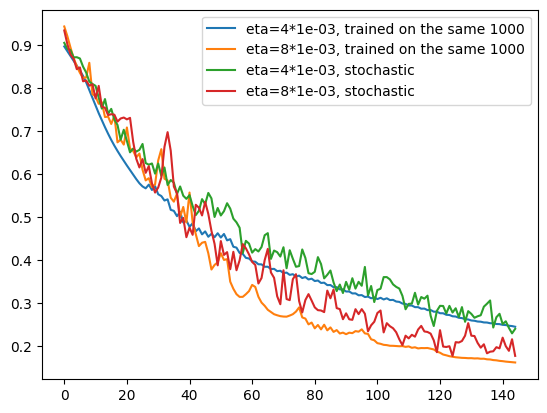

In [14]:
plt.plot(previous_costs_4[5:-1], label="eta=4*1e-03, trained on the same 1000")
plt.plot(previous_costs_8[5:-1], label="eta=8*1e-03, trained on the same 1000")
plt.plot(previous_costs_4_stochastic[5:-1], label="eta=4*1e-03, stochastic")
plt.plot(previous_costs_8_stochastic[5:-1], label="eta=8*1e-03, stochastic")
plt.legend()

Il y a un pb, il ne se passe pas ce que j'imagine, car ils devraient tous partir du même endroit.

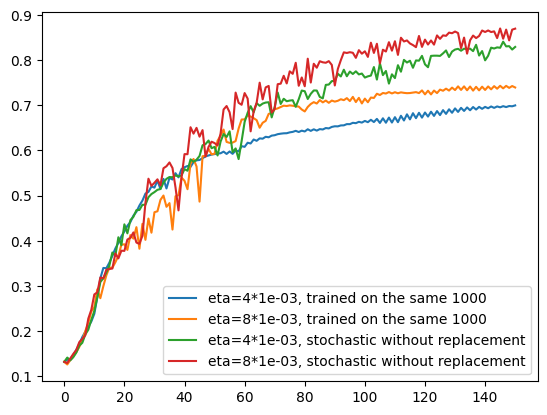

In [15]:
plt.plot(previous_accuracies_4, label="eta=4*1e-03, trained on the same 1000")
plt.plot(previous_accuracies_8, label="eta=8*1e-03, trained on the same 1000")
plt.plot(previous_accuracies_4_stochastic, label="eta=4*1e-03, stochastic without replacement")
plt.plot(previous_accuracies_8_stochastic, label="eta=8*1e-03, stochastic without replacement")
plt.legend()

Et bien étonnament, n'apporte rien cette fonctionnalité stochastique. Etonnant. Peut-être en autorisant les replacement ce serait mieux ? Essayons.

In [ ]:
import src

In [17]:
src.script.save_object(object=previous_costs_4, name="previous_costs_4_trained_on_the_same_1000")
src.script.save_object(object=previous_costs_8, name="previous_costs_8_trained_on_the_same_1000")
src.script.save_object(object=previous_accuracies_4, name="previous_accuracies_4_trained_on_the_same_1000")
src.script.save_object(object=previous_accuracies_8, name="previous_accuracies_8_trained_on_the_same_1000")


Text(0.5, 0.98, 'Miss of particular cases when training only on a fixed subset of 1000 images, solved by randomly selecting at each training step 1000 images to train on. Training on the whole dataset would be impractical (size 60000)')

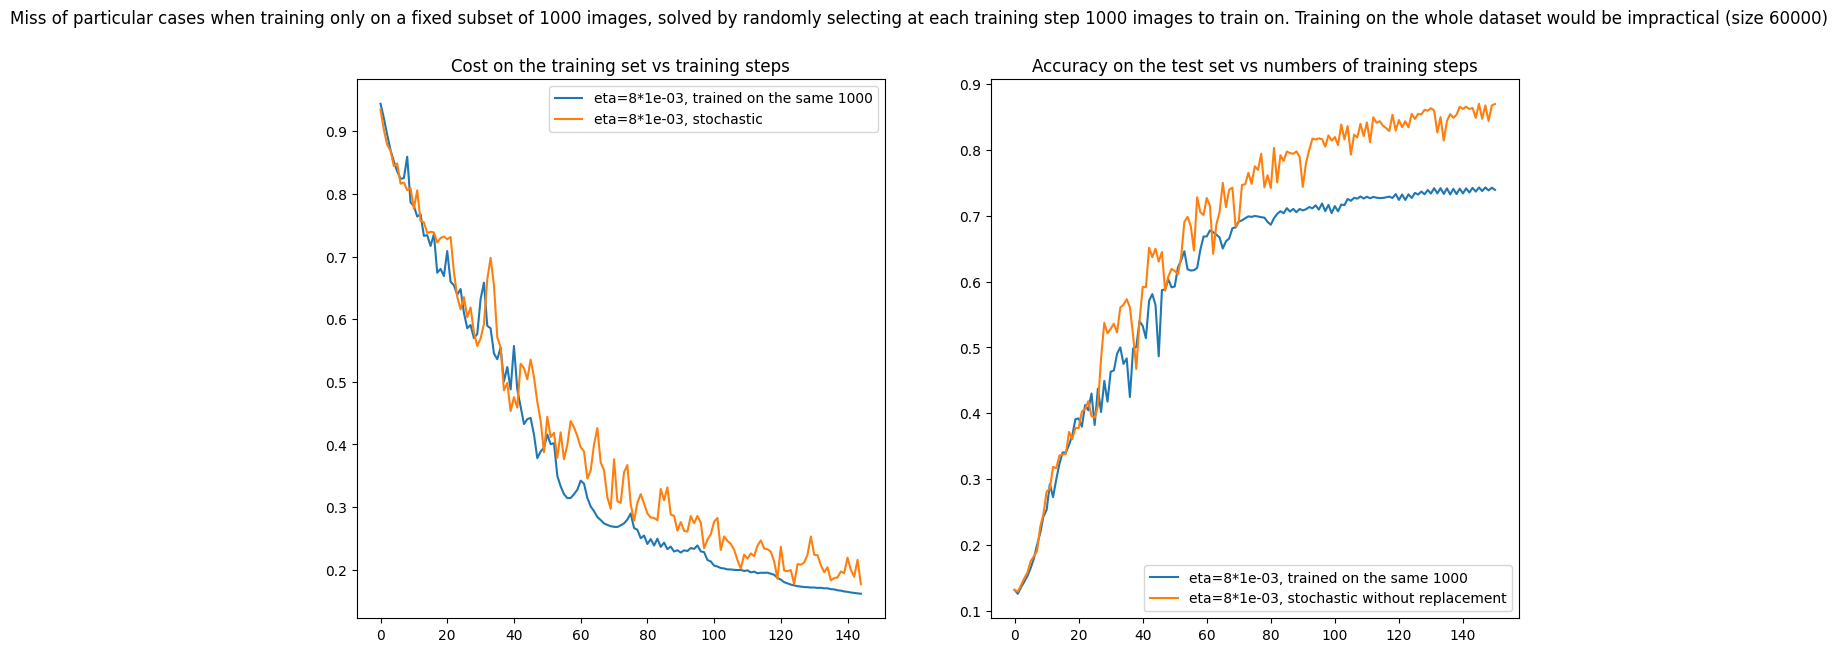

In [34]:
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plt.plot(previous_costs_8[5:-1], label="eta=8*1e-03, trained on the same 1000")
plt.plot(previous_costs_8_stochastic[5:-1], label="eta=8*1e-03, stochastic")
plt.legend()
plt.title("Cost on the training set vs training steps")
plt.subplot(1,2,2)
plt.plot(previous_accuracies_8, label="eta=8*1e-03, trained on the same 1000")
plt.plot(previous_accuracies_8_stochastic, label="eta=8*1e-03, stochastic without replacement")
plt.title("Accuracy on the test set vs numbers of training steps")
plt.legend()
plt.suptitle("Miss of particular cases when training only on a fixed subset of 1000 images, solved by randomly selecting at each training step 1000 images to train on. Training on the whole dataset would be impractical (size 60000)")
